# WSEI Deep Learning – Lab 06

## Surrogate-Based Prediction of CNN Accuracy for CIFAR-10

System przewidujący **Accuracy** architektury CNN na CIFAR-10 na podstawie opisu architektury.

| Komponent | Opis |
|-----------|------|
| Generator | Hugging Face `AutoModelForCausalLM.from_pretrained` → JSON |
| Encoding | Wektor stałej długości `[type, p1, p2] × 15` |
| Surrogate | MLP + XGBoost |
| Pipeline | LLM → encode → predict → train jeśli obiecujące → retrain |

Ustaw `FAST_MODE` w `surrogate_cnn/config.py` (`True` = szybki test, `False` = pełny przebieg 50–60 architektur).


In [ ]:
# %pip install torch torchvision transformers accelerate xgboost scikit-learn scipy matplotlib pandas


In [1]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch

ROOT = Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from surrogate_cnn.config import (
    ARCHIVE_PATH,
    FAST_MODE,
    HF_MODEL_NAME,
    INITIAL_ARCH_COUNT,
    ITERATIONS,
    TRAIN_EPOCHS,
)
from surrogate_cnn.encoding import encode_architecture, decode_vector_preview
from surrogate_cnn.architecture import validate_architecture
from surrogate_cnn.builder import build_model, count_parameters
from surrogate_cnn.llm_generator import generate_architecture, llm_available
from surrogate_cnn.pipeline import (
    run_initial_collection,
    run_iterative_search,
    load_dataset,
    evaluate_all_surrogates,
)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)
print("FAST_MODE:", FAST_MODE)
print("HF_MODEL_NAME:", HF_MODEL_NAME)
print("Transformers OK:", llm_available())
print("Epoki CNN:", TRAIN_EPOCHS, "| Architektur start:", INITIAL_ARCH_COUNT)


c:\Users\mateu\Desktop\dyplom\nlp\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Device: cuda
FAST_MODE: False
HF_MODEL_NAME: Qwen/Qwen3.5-2B
Transformers OK: True
Epoki CNN: 15 | Architektur start: 60


## 1. Przykład architektury i encoding

Kody warstw: **1** Conv, **2** MaxPool, **3** Dropout, **4** Linear, **5** BatchNorm, **6** ReLU, **7** GAP.


In [2]:
example = {
    "layers": [
        {"type": "conv", "filters": 32, "kernel": 3},
        {"type": "conv", "filters": 64, "kernel": 3},
        {"type": "maxpool"},
        {"type": "dropout", "p": 0.2},
        {"type": "globalaveragepooling"},
        {"type": "linear", "units": 128},
    ]
}

ok, msg = validate_architecture(example)
vec = encode_architecture(example)
model = build_model(example)

print("Walidacja:", ok, "-", msg)
print("Parametry:", f"{count_parameters(model):,}")
print("Wektor (pierwsze 12):", vec[:12].tolist())
print("Odczyt:", " -> ".join(decode_vector_preview(vec)))


Walidacja: True - ok
Parametry: 29,002
Wektor (pierwsze 12): [1.0, 32.0, 3.0, 1.0, 64.0, 3.0, 2.0, 0.0, 0.0, 3.0, 0.20000000298023224, 0.0]
Odczyt: Conv(32,3) -> Conv(64,3) -> MaxPool -> Dropout(0.20000000298023224) -> GAP -> Linear(128)


## 2. Generator architektur (Hugging Face + fallback)

LLM generuje JSON. Przy błędzie lub niepoprawnej architekturze używany jest generator losowy ze search space.


In [3]:
arch, source = generate_architecture(use_llm=True)
print("Zrodlo:", source)
print("Architektura:", arch)
ok, msg = validate_architecture(arch)
print("Walidacja:", ok, msg)


[transformers] `torch_dtype` is deprecated! Use `dtype` instead!
[transformers] The fast path is not available because one of the required library is not installed. Falling back to torch implementation. To install follow https://github.com/fla-org/flash-linear-attention#installation and https://github.com/Dao-AILab/causal-conv1d
Loading weights: 100%|██████████| 320/320 [00:04<00:00, 73.09it/s] 


Zrodlo: hf
Architektura: {'layers': [{'type': 'conv', 'filters': 32, 'kernel': 3}, {'type': 'batchnorm'}, {'type': 'relu'}, {'type': 'maxpool'}, {'type': 'dropout', 'p': 0.25}, {'type': 'conv', 'filters': 64, 'kernel': 3}, {'type': 'batchnorm'}, {'type': 'relu'}, {'type': 'maxpool'}, {'type': 'batchnorm'}, {'type': 'relu'}, {'type': 'conv', 'filters': 128, 'kernel': 5}, {'type': 'batchnorm'}, {'type': 'relu'}, {'type': 'globalaveragepooling'}, {'type': 'linear', 'units': 512}]}
Walidacja: True ok


## 3. Początkowy dataset (trening CNN na CIFAR-10)

Każda architektura: budowa PyTorch → trening → zapis Accuracy do `data/surrogate_cnn/architectures.json`.



In [4]:
records = run_initial_collection(device=device, use_llm=True)
print(f"Zebrano {len(records)} architektur")
print("Plik:", ARCHIVE_PATH)

df = pd.DataFrame([
    {"id": i + 1, "accuracy_pct": r["accuracy_pct"], "source": r["source"]}
    for i, r in enumerate(records)
])
df.sort_values("accuracy_pct", ascending=False).head(10)


Generowanie i trening 7 architektur (device=cuda)...
[1/7] Źródło: hf
  Accuracy: 76.21%
[2/7] Źródło: hf
  Accuracy: 64.79%
[3/7] Źródło: hf
  Accuracy: 67.38%
[4/7] Źródło: hf
  Accuracy: 34.69%
[5/7] Źródło: hf
  Accuracy: 35.32%
[6/7] Źródło: hf
  Accuracy: 34.95%
[7/7] Źródło: hf
  Accuracy: 67.6%
Zebrano 60 architektur
Plik: C:\Users\mateu\Desktop\dyplom\nlp\data\surrogate_cnn\architectures.json


,id,accuracy_pct,source
4,5,88.66,hf
33,34,85.90,hf
29,30,85.34,hf
5,6,84.44,hf
18,19,84.26,hf
27,28,81.97,hf
10,11,81.08,hf
12,13,80.71,hf
16,17,80.58,hf
11,12,80.19,hf


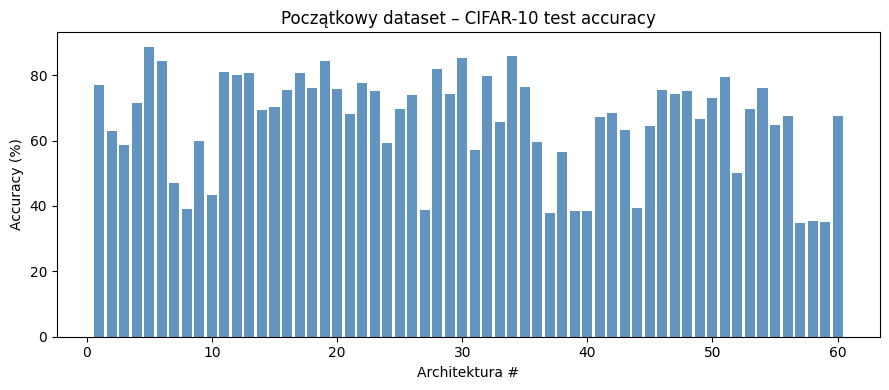

In [5]:
if len(df) > 0:
    fig, ax = plt.subplots(figsize=(9, 4))
    ax.bar(df["id"], df["accuracy_pct"], color="steelblue", alpha=0.85)
    ax.set_xlabel("Architektura #")
    ax.set_ylabel("Accuracy (%)")
    ax.set_title("Początkowy dataset – CIFAR-10 test accuracy")
    plt.tight_layout()
    plt.show()
else:
    print("Brak danych do wykresu.")


## 4. Modele surogatowe (MLP + XGBoost)

Predykcja: `wektor architektury → Accuracy` (0–1).

Metryki: **MAE**, **RMSE**, **R²**, **Spearman**.


In [6]:
if len(records) >= 5:
    metric_rows = evaluate_all_surrogates(records, device)
else:
    print("Potrzeba co najmniej 5 architektur do sensownej ewaluacji surrogate.")


Model             MAE     RMSE       R2   Spearman
--------------------------------------------------
MLP            0.0356   0.0697   0.7870     0.9580
XGBoost        0.1386   0.1574  -0.0865     0.3023


## 5. Iteracyjny pipeline NAS

1. LLM → architektura JSON  
2. Encoding  
3. Surrogate przewiduje Accuracy  
4. Jeśli `predicted > best` → pełny trening CNN  
5. Dodanie do datasetu + ponowne uczenie surrogate


In [9]:
records = run_iterative_search(iterations=60, device=device, use_llm=True)


Start: 62 architektur, najlepsze Accuracy = 88.66%

Iteracja 1/60 | źródło=hf | pred MLP=75.6% XGB=64.9%
  Pominięto trening (pred 70.29% <= best 88.66%)

Iteracja 2/60 | źródło=hf | pred MLP=87.0% XGB=63.3%
  Pominięto trening (pred 75.15% <= best 88.66%)

Iteracja 3/60 | źródło=hf | pred MLP=75.4% XGB=64.7%
  Pominięto trening (pred 70.03% <= best 88.66%)

Iteracja 4/60 | źródło=hf | pred MLP=73.4% XGB=64.9%
  Pominięto trening (pred 69.19% <= best 88.66%)

Iteracja 5/60 | źródło=hf | pred MLP=275.0% XGB=63.9%
  Predykcja lepsza – pełny trening CNN...
  Rzeczywiste Accuracy: 45.02%

Iteracja 6/60 | źródło=hf | pred MLP=85.7% XGB=43.7%
  Pominięto trening (pred 64.69% <= best 88.66%)

Iteracja 7/60 | źródło=hf | pred MLP=71.3% XGB=43.8%
  Pominięto trening (pred 57.57% <= best 88.66%)

Iteracja 8/60 | źródło=hf | pred MLP=71.1% XGB=70.2%
  Pominięto trening (pred 70.68% <= best 88.66%)

Iteracja 9/60 | źródło=hf | pred MLP=51.8% XGB=55.8%
  Pominięto trening (pred 53.80% <= best 88.66

In [10]:
top = sorted(records, key=lambda r: -r["accuracy"])[:15]
final_df = pd.DataFrame([
    {"CNN": f"#{i+1}", "Accuracy": f"{r['accuracy_pct']}%", "source": r["source"]}
    for i, r in enumerate(top)
])
print("Top architektury:")
final_df


Top architektury:


,CNN,Accuracy,source
0,#1,88.66%,hf
1,#2,85.9%,hf
2,#3,85.34%,hf
3,#4,84.44%,hf
4,#5,84.26%,hf
5,#6,81.97%,hf
6,#7,81.08%,hf
7,#8,80.71%,hf
8,#9,80.58%,hf
9,#10,80.19%,hf


## 6. Podsumowanie

- Zaimplementowano encoding, walidację search space i budowę modeli PyTorch.
- Surrogate **MLP** i **XGBoost** przewidują Accuracy bez treningu każdej propozycji.
- Pipeline iteracyjny trenuje w pełni tylko obiecujące architektury.
- Konfiguracja: `surrogate_cnn/config.py` (`HF_MODEL_NAME`, `FAST_MODE`, `INITIAL_ARCH_COUNT`).


- Wyniki: 14/15 najlepszych to początkowy zbiór hf (max 88,66%). Iteracyjny NAS dodał głównie hf_iter23 (77%, #14); 60 iteracji mało zmieniło ranking.

- Pipeline: Filtr ensemble (MLP + XGB) jest zawodny — wysoki próg (best ≈ 89%) i słabe predykcje XGB ograniczają eksplorację.

- Wniosek: Surrogate przyspiesza NAS tylko przy dobrym modelu i większym datasetcie; tu sensowniejszy jest MLP bez XGBoosta w ensemble.

